In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np
import sys
from pathlib import Path

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder



In [3]:
df = pd.read_parquet("../../../1_download_data/model_ready/flights_model_ready.parquet")
df.head()

,FlightDate,Airline,Origin,Dest,CRSDepTime,CRSElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepTimeBlk,CRSArrTime,ArrTimeBlk,DistanceGroup,year,target,date,dep_hour,tmpf,vsby,sknt,p01i,relh,gust,DayOfWeek_num,month_sin,month_cos,dow_sin,dow_cos,Distance_std,tmpf_std,vsby_std,sknt_std,relh_std,gust_std,distance_origin_norm,has_precip,is_holiday,prev_day_failure_origin,is_morning_peak,is_evening_peak
0,2018-01-03,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,3,Wednesday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,Delayed,2018-01-03,10,27.0,10.0,6.000000,0.0,40.42,0.0,2,0.5,0.866025,0.974928,-0.222521,-1.181369,-1.795908,0.372,-0.268741,-1.032586,-0.532803,-506.21629,0,0,1,0,0
1,2018-01-04,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,4,Thursday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N981EV,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-04,10,24.1,10.0,14.166667,0.0,54.36,21.0,3,0.5,0.866025,0.433884,-0.900969,-1.181369,-1.949265,0.372,1.558113,-0.405039,1.744748,-506.21629,0,0,1,0,0
2,2018-01-05,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,5,Friday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8877A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-05,10,17.1,10.0,12.153846,0.0,55.51,0.0,4,0.5,0.866025,-0.433884,-0.900969,-1.181369,-2.319438,0.372,1.107853,-0.353268,-0.532803,-506.21629,0,0,1,0,0
3,2018-01-06,Endeavor Air Inc.,ATL,ABY,1037,59.0,145.0,2018,1,1,6,Saturday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8970D,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1136,1100-1159,1,2018,On time,2018-01-06,10,21.9,10.0,6.846154,0.0,57.02,0.0,5,0.5,0.866025,-0.974928,-0.222521,-1.181369,-2.065605,0.372,-0.079459,-0.285291,-0.532803,-506.21629,0,0,1,0,0
4,2018-01-07,Endeavor Air Inc.,ATL,ABY,1037,60.0,145.0,2018,1,1,7,Sunday,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8980A,3298,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,1000-1059,1137,1100-1159,1,2018,On time,2018-01-07,10,21.9,10.0,7.384615,0.0,54.75,0.0,6,0.5,0.866025,-0.781831,0.623490,-1.181369,-2.065605,0.372,0.040993,-0.387482,-0.532803,-506.21629,0,0,1,0,0


In [4]:
df.columns

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'CRSDepTime',
       'CRSElapsedTime', 'Distance', 'Year', 'Quarter', 'Month', 'DayofMonth',
       'DayOfWeek', 'Marketing_Airline_Network',
       'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline',
       'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline',
       'Operating_Airline', 'DOT_ID_Operating_Airline',
       'IATA_Code_Operating_Airline', 'Tail_Number',
       'Flight_Number_Operating_Airline', 'OriginAirportID',
       'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName',
       'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac',
       'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestCityName',
       'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepTimeBlk',
       'CRSArrTime', 'ArrTimeBlk', 'DistanceGroup', 'year', 'target', 'date',
       'dep_hour', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust',
       'DayOfWeek_num', 'month_sin', 'mon

In [5]:
# df = df[['FlightDate', 'Airline', 'Origin', 'Dest',
#         'Distance', 'Year',  'Month', 
#        'DayOfWeek',
#        'DepTimeBlk',
#        'DistanceGroup', 
#        'dep_hour', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust',
#        #'DayOfWeek_num', 
#        'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
#        'Distance_std', 
#       # 'tmpf_std', 'vsby_std', 'sknt_std', 'relh_std', 'gust_std', 
#        'distance_origin_norm', 'has_precip', 'is_holiday',
#        'prev_day_failure_origin', 'is_morning_peak', 'is_evening_peak','target']]

In [7]:
# X_train, X_test, y_train, y_test = sample_and_split(
#     df,
#     total_sample=500_000,
#     max_origin_frac=0.05,
#     max_region_frac=0.3,
#     test_size=0.2,
#     output_dir="../../data/model_ready/sampled_splits",
#     random_state=42
# )

In [8]:
train_df = pd.read_parquet("../../../1_download_data/model_ready/sampled_splits/train.parquet")
test_df = pd.read_parquet("../../../1_download_data/model_ready/sampled_splits/test.parquet")
print(f"train shape: {train_df.shape}")
print(f"test shape: {test_df.shape}")

X_train = train_df.drop(columns = "target", axis =1)
y_train = train_df.target


X_test = test_df.drop(columns = "target", axis =1)
y_test = test_df.target

train shape: (179519, 71)
test shape: (44880, 71)


### Let's start to build up our model one feature at a time

In [9]:
# Encode target to integers
le_target = LabelEncoder()
df['target_enc'] = le_target.fit_transform(df['target'])


In [10]:
# Assume these are your columns
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
numeric_features = [col for col in numeric_features if col != 'target_enc']

categorical_features = df.select_dtypes(include='object').columns.tolist()
categorical_features = [col for col in categorical_features if col != 'target']


In [11]:
from sklearn.feature_selection import f_classif

X_num = df[numeric_features]
y = df['target_enc']
X_num = X_num.fillna(0)



In [12]:
f_vals, p_vals = f_classif(X_num, y)
numeric_corr = pd.Series(f_vals, index=numeric_features).sort_values(ascending=False)

In [13]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    phi2 = chi2/n
    r,k = contingency.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

categorical_corr = {}
for col in categorical_features:
    categorical_corr[col] = cramers_v(df[col], df['target_enc'])

categorical_corr = pd.Series(categorical_corr).sort_values(ascending=False)


In [14]:
all_corr = pd.concat([numeric_corr, categorical_corr])
all_corr = all_corr.sort_values(ascending=False)
print("Top correlated features with target:")
print(all_corr.head(10))


Top correlated features with target:
CRSDepTime         182433.421383
dep_hour           181855.725445
is_morning_peak    116788.369786
is_evening_peak    113915.737200
CRSArrTime          91004.028019
has_precip          72789.695920
sknt                65737.244705
sknt_std            65737.244703
vsby_std            59050.770573
vsby                59050.770573
dtype: float64


In [15]:
all_corr[0:20]

CRSDepTime         182433.421383
dep_hour           181855.725445
is_morning_peak    116788.369786
is_evening_peak    113915.737200
CRSArrTime          91004.028019
has_precip          72789.695920
sknt                65737.244705
sknt_std            65737.244703
vsby_std            59050.770573
vsby                59050.770573
gust                53083.132313
gust_std            53083.132302
tmpf                34742.363889
tmpf_std            34742.363886
p01i                31415.140013
month_cos           17735.543132
Month               15253.111766
Quarter             14737.401905
relh_std            13588.869891
relh                13467.538226
dtype: float64

Now lets iterate through some variables to see results of performance

In [16]:
FEATURES = ["dep_hour" ,       
"is_morning_peak"   ,
"is_evening_peak"  ,
"has_precip" ,
"sknt" ,
"vsby" ,
"gust" ,
"tmpf"  
]

TARGET = "target"




In [17]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Split categorical vs numerical
# categorical_features = [
#     "DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup", "DayOfWeek"
# ]

numeric_features = [
    "dep_hour" ,       
"is_morning_peak"   ,
"is_evening_peak"  ,
"has_precip" ,
"sknt" ,
"vsby" ,
"gust" ,
"tmpf"  
]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
       # ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [18]:
rf_model = RandomForestClassifier(class_weight="balanced",
    n_estimators=80,
    max_depth=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)

In [19]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("rf", rf_model)
])

In [20]:
for col in numeric_features:
    X_train[col] = X_train[col].fillna(0)
    X_test[col]  = X_test[col].fillna(0)


In [21]:
pipeline.fit(X_train[FEATURES], y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['dep_hour',
                                                   'is_morning_peak',
                                                   'is_evening_peak',
                                                   'has_precip', 'sknt', 'vsby',
                                                   'gust', 'tmpf'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_estimators=80, n_jobs=-1,
                                        random_state=42))])

In [22]:
# Predictions
y_pred = pipeline.predict(X_test[FEATURES])

# Metrics
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

# Confusion matrix (normalized)
cm = confusion_matrix(y_test, y_pred, normalize="true")
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)
print("\nNormalized Confusion Matrix:\n")
print(cm_df)


Classification Report:

              precision    recall  f1-score   support

   Cancelled      0.177     0.166     0.172      1587
     Delayed      0.446     0.572     0.501     15836
     On time      0.705     0.592     0.643     27457

    accuracy                          0.570     44880
   macro avg      0.443     0.444     0.439     44880
weighted avg      0.595     0.570     0.577     44880


Normalized Confusion Matrix:

           Cancelled   Delayed   On time
Cancelled   0.166352  0.436673  0.396975
Delayed     0.037888  0.572493  0.389619
On time     0.022763  0.385403  0.591835


Test Accuracy: 0.570

Confusion Matrix (counts):
           Cancelled  Delayed  On time
Cancelled        264      693      630
Delayed          600     9066     6170
On time          625    10582    16250

Confusion Matrix (normalized):
           Cancelled   Delayed   On time
Cancelled   0.166352  0.436673  0.396975
Delayed     0.037888  0.572493  0.389619
On time     0.022763  0.385403  0.591835


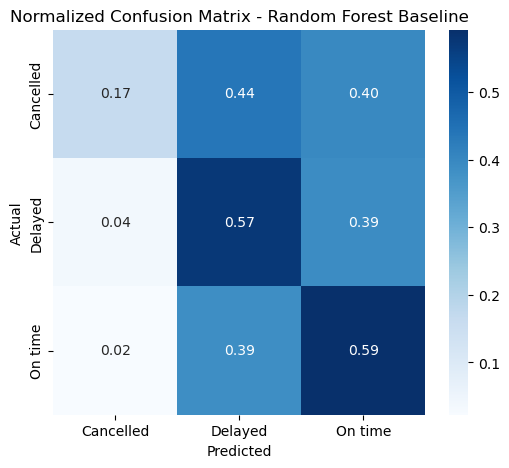


Classification Report:
              precision    recall  f1-score   support

   Cancelled      0.177     0.166     0.172      1587
     Delayed      0.446     0.572     0.501     15836
     On time      0.705     0.592     0.643     27457

    accuracy                          0.570     44880
   macro avg      0.443     0.444     0.439     44880
weighted avg      0.595     0.570     0.577     44880



In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Make predictions on test set
# -----------------------------
y_pred = pipeline.predict(X_test[FEATURES])
y_true = y_test

# -----------------------------
# Step 2: Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.3f}")

# -----------------------------
# Step 3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_)
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (counts):")
print(cm_df)

# Optional: normalized confusion matrix
cm_norm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_, normalize='true')
cm_norm_df = pd.DataFrame(cm_norm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (normalized):")
print(cm_norm_df)

# -----------------------------
# Step 4: Plot normalized confusion matrix
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix - Random Forest Baseline")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# -----------------------------
# Step 5: Optional detailed classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=3))

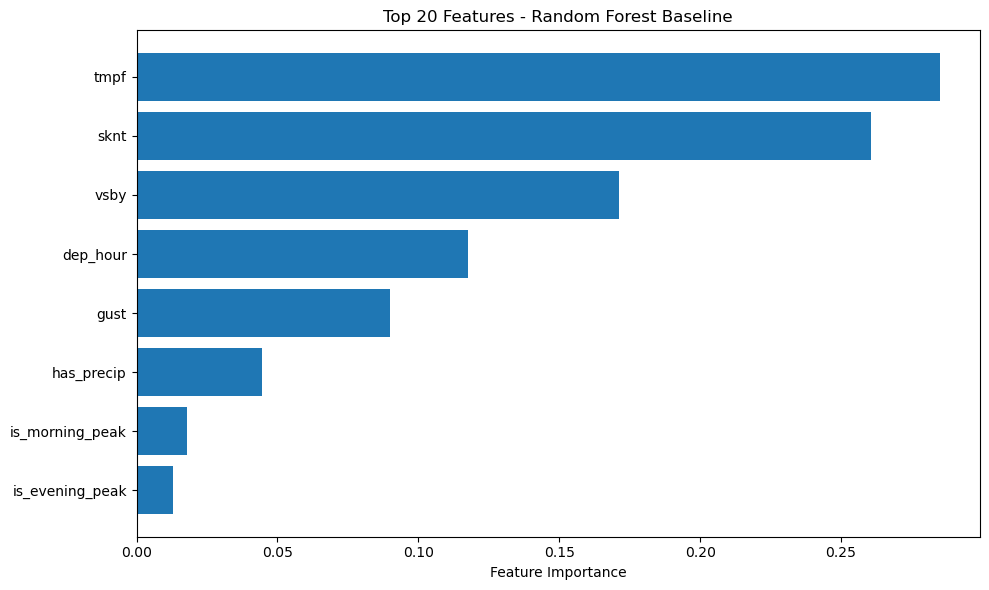

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# STEP 1: Extract feature names after one-hot encoding
# -----------------------------
# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocess"]
rf_model = pipeline.named_steps["rf"]

# Get categorical feature names after one-hot
#cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
#all_features = np.concatenate([cat_features, numeric_features])
all_features = np.array(numeric_features)

# -----------------------------
# STEP 2: Extract feature importances
# -----------------------------
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
sorted_features = all_features[indices]
sorted_importances = importances[indices]

# -----------------------------
# STEP 3: Plot top 20 features
# -----------------------------
top_n = 8
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), sorted_importances[:top_n][::-1], align="center")
plt.yticks(range(top_n), sorted_features[:top_n][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features - Random Forest Baseline")
plt.tight_layout()
plt.show()

### Let's keep class balances parameter, but play around with the features. Let's add an additional 2 variables to see if it performs better

In [25]:
FEATURES = ["dep_hour" ,       
"is_morning_peak"   ,
"is_evening_peak"  ,
"has_precip" ,
"sknt" ,
"vsby" ,
"gust" ,
"tmpf" ,
"p01i",
"month_cos"
]

TARGET = "target"


# # Split categorical vs numerical
# categorical_features = [
#     "DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup", "DayOfWeek"
# ]

numeric_features = [
"dep_hour" ,       
"is_morning_peak"   ,
"is_evening_peak"  ,
"has_precip" ,
"sknt" ,
"vsby" ,
"gust" ,
"tmpf" ,
"p01i",
"month_cos"
]

In [26]:

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
       # ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)



In [27]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.ensemble import RandomForestClassifier


# Class-weighted Random Forest
rf_model = RandomForestClassifier(
    class_weight="balanced",
    n_estimators=80,
    max_depth=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)


# Full pipeline
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('rf', rf_model)
])


In [28]:
# # Fill numeric NaNs with 0
for col in numeric_features:
    X_train[col] = X_train[col].fillna(0)
    X_test[col]  = X_test[col].fillna(0)

In [29]:
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['dep_hour',
                                                   'is_morning_peak',
                                                   'is_evening_peak',
                                                   'has_precip', 'sknt', 'vsby',
                                                   'gust', 'tmpf', 'p01i',
                                                   'month_cos'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_estimators=80, n_jobs=-1,
                                        random_state=42))])

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = pipeline.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix (counts):")
print(confusion_matrix(y_test, y_pred))

# Optional: normalized confusion matrix
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
print("Confusion Matrix (normalized):")
print(np.round(cm_norm, 3))


Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.19      0.20      0.19      1587
     Delayed       0.46      0.54      0.50     15836
     On time       0.71      0.63      0.67     27457

    accuracy                           0.58     44880
   macro avg       0.45      0.46      0.45     44880
weighted avg       0.60      0.58      0.59     44880

Confusion Matrix (counts):
[[  313   646   628]
 [  633  8579  6624]
 [  683  9432 17342]]
Confusion Matrix (normalized):
[[0.197 0.407 0.396]
 [0.04  0.542 0.418]
 [0.025 0.344 0.632]]


Test Accuracy: 0.585

Confusion Matrix (counts):
           Cancelled  Delayed  On time
Cancelled        313      646      628
Delayed          633     8579     6624
On time          683     9432    17342

Confusion Matrix (normalized):
           Cancelled   Delayed   On time
Cancelled   0.197227  0.407057  0.395715
Delayed     0.039972  0.541740  0.418287
On time     0.024875  0.343519  0.631606


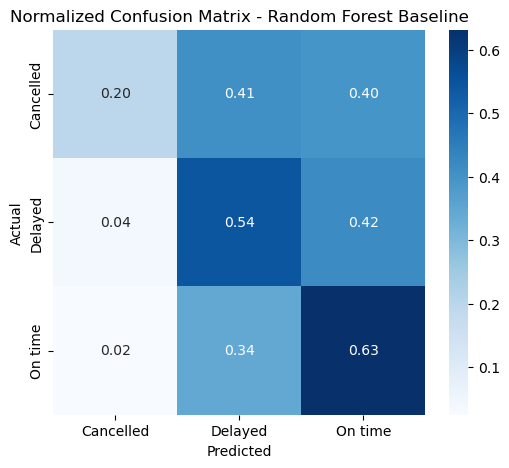


Classification Report:
              precision    recall  f1-score   support

   Cancelled      0.192     0.197     0.195      1587
     Delayed      0.460     0.542     0.497     15836
     On time      0.705     0.632     0.666     27457

    accuracy                          0.585     44880
   macro avg      0.452     0.457     0.453     44880
weighted avg      0.600     0.585     0.590     44880



In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Make predictions on test set
# -----------------------------
y_pred = pipeline.predict(X_test[FEATURES])
y_true = y_test

# -----------------------------
# Step 2: Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.3f}")

# -----------------------------
# Step 3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_)
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (counts):")
print(cm_df)

# Optional: normalized confusion matrix
cm_norm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_, normalize='true')
cm_norm_df = pd.DataFrame(cm_norm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (normalized):")
print(cm_norm_df)

# -----------------------------
# Step 4: Plot normalized confusion matrix
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix - Random Forest Baseline")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# -----------------------------
# Step 5: Optional detailed classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=3))

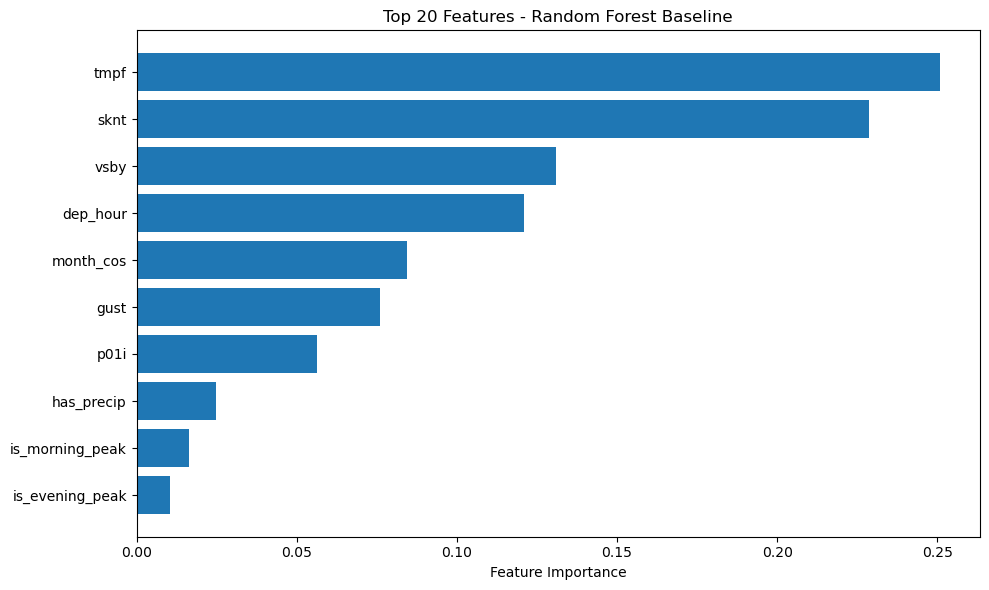

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# STEP 1: Extract feature names after one-hot encoding
# -----------------------------
# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocess"]
rf_model = pipeline.named_steps["rf"]

# Get categorical feature names after one-hot
#cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
#all_features = np.concatenate([cat_features, numeric_features])
all_features = np.array(numeric_features)


# -----------------------------
# STEP 2: Extract feature importances
# -----------------------------
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]

sorted_features = all_features[indices]

sorted_importances = importances[indices]

# -----------------------------
# STEP 3: Plot top 20 features
# -----------------------------
top_n = 10
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), sorted_importances[:top_n][::-1], align="center")
plt.yticks(range(top_n), sorted_features[:top_n][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features - Random Forest Baseline")
plt.tight_layout()
plt.show()


Let's just add most of the variables we have - maybe we are missing the most important variable

In [33]:
X_train.columns

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'CRSDepTime',
       'CRSElapsedTime', 'Distance', 'Year', 'Quarter', 'Month', 'DayofMonth',
       'DayOfWeek', 'Marketing_Airline_Network',
       'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline',
       'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline',
       'Operating_Airline', 'DOT_ID_Operating_Airline',
       'IATA_Code_Operating_Airline', 'Tail_Number',
       'Flight_Number_Operating_Airline', 'OriginAirportID',
       'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName',
       'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac',
       'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestCityName',
       'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepTimeBlk',
       'CRSArrTime', 'ArrTimeBlk', 'DistanceGroup', 'year', 'date', 'dep_hour',
       'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust', 'DayOfWeek_num',
       'month_sin', 'month_cos', '

In [34]:
FEATURES = ['Airline', 'Origin', 'Dest',
        'Distance', 'Year',  'Month', 
       'DayOfWeek',
       'DepTimeBlk',
       'DistanceGroup', 
       'dep_hour', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust',
       'DayOfWeek_num', 
       'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
       'Distance_std', 
       'tmpf_std', 'vsby_std', 'sknt_std', 'relh_std', 'gust_std', 
       'distance_origin_norm', 'has_precip', 'is_holiday',
       'prev_day_failure_origin', 'is_morning_peak', 'is_evening_peak']

TARGET = "target"


# # Split categorical vs numerical
categorical_features = [
    "DepTimeBlk", "Airline", "Origin", "Dest", "DistanceGroup", "DayOfWeek"
]

numeric_features = [
"dep_hour" ,       
"is_morning_peak"   ,
"is_evening_peak"  ,
"has_precip" ,
"sknt" ,
"vsby" ,
"gust" ,
"tmpf" ,
"p01i",
"month_cos",
'prev_day_failure_origin',
'is_holiday',
'distance_origin_norm',
'DayOfWeek_num', 
'month_sin', 'dow_sin', 'dow_cos',
'Distance_std', 
'tmpf_std', 'vsby_std', 'sknt_std', 'relh_std', 'gust_std', 'relh', 'Distance', 'Year', 'Month'
]

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
       ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [36]:
# Class-weighted Random Forest
rf_model = RandomForestClassifier(
    class_weight="balanced",
    n_estimators=80,
    max_depth=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42)


# Full pipeline
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('rf', rf_model)
])

In [37]:
# # Fill numeric NaNs with 0
for col in numeric_features:
    X_train[col] = X_train[col].fillna(0)
    X_test[col]  = X_test[col].fillna(0)

In [38]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['dep_hour',
                                                   'is_morning_peak',
                                                   'is_evening_peak',
                                                   'has_precip', 'sknt', 'vsby',
                                                   'gust', 'tmpf', 'p01i',
                                                   'month_cos',
                                                   'prev_day_failure_origin',
                                                   'is_holiday',
                                                   'distance_origin_norm',
                                                   'DayOfWeek_num', 'month_sin',
                                                   'dow_sin', 'dow_cos',
                                                   'Distance_std', 'tmpf_std',
                                                   'vsby_std', 'sknt_std',
                                                   'relh_std', 'gust_std',
                                                   'relh', 'Distance', 'Year',
                                                   'Month']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['DepTimeBlk', 'Airline',
                                                   'Origin', 'Dest',
                                                   'DistanceGroup',
                                                   'DayOfWeek'])])),
                ('rf',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_estimators=80, n_jobs=-1,
                                        random_state=42))])

Test Accuracy: 0.596

Confusion Matrix (counts):
           Cancelled  Delayed  On time
Cancelled        489      581      517
Delayed         1061     8863     5912
On time         1079     8998    17380

Confusion Matrix (normalized):
           Cancelled   Delayed   On time
Cancelled   0.308129  0.366100  0.325772
Delayed     0.066999  0.559674  0.373327
On time     0.039298  0.327712  0.632990


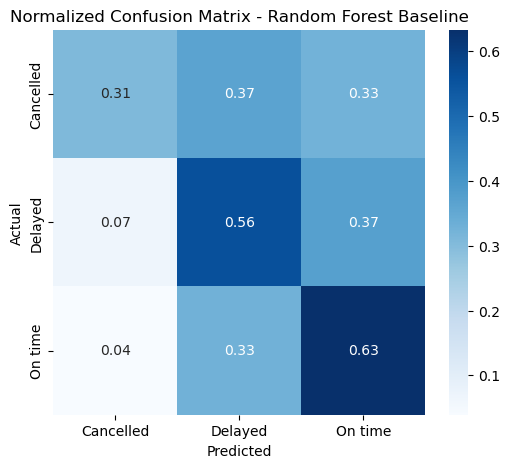


Classification Report:
              precision    recall  f1-score   support

   Cancelled      0.186     0.308     0.232      1587
     Delayed      0.481     0.560     0.517     15836
     On time      0.730     0.633     0.678     27457

    accuracy                          0.596     44880
   macro avg      0.466     0.500     0.476     44880
weighted avg      0.623     0.596     0.605     44880



In [39]:
# -----------------------------
y_pred = pipeline.predict(X_test[FEATURES])
y_true = y_test

# -----------------------------
# Step 2: Accuracy
# -----------------------------
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.3f}")

# -----------------------------
# Step 3: Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_)
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (counts):")
print(cm_df)

# Optional: normalized confusion matrix
cm_norm = confusion_matrix(y_true, y_pred, labels=pipeline.classes_, normalize='true')
cm_norm_df = pd.DataFrame(cm_norm, index=pipeline.classes_, columns=pipeline.classes_)

print("\nConfusion Matrix (normalized):")
print(cm_norm_df)

# -----------------------------
# Step 4: Plot normalized confusion matrix
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix - Random Forest Baseline")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# -----------------------------
# Step 5: Optional detailed classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=3))

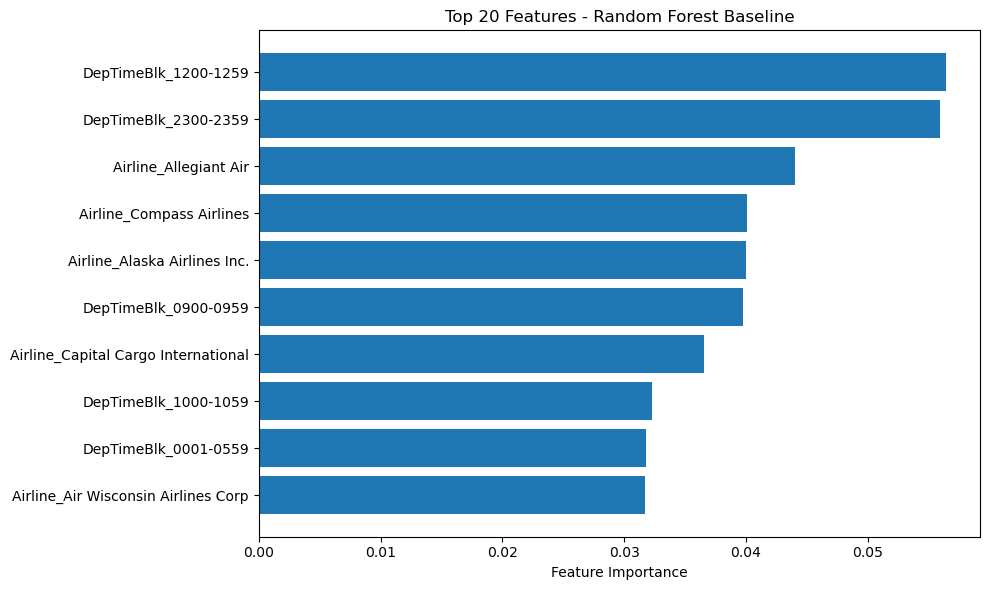

In [40]:

# -----------------------------
# STEP 1: Extract feature names after one-hot encoding
# -----------------------------
# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocess"]
rf_model = pipeline.named_steps["rf"]

# Get categorical feature names after one-hot
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_features = np.concatenate([cat_features, numeric_features])

#all_features = np.array(numeric_features)


# -----------------------------
# STEP 2: Extract feature importances
# -----------------------------
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]

sorted_features = all_features[indices]

sorted_importances = importances[indices]

# -----------------------------
# STEP 3: Plot top 20 features
# -----------------------------
top_n = 10
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), sorted_importances[:top_n][::-1], align="center")
plt.yticks(range(top_n), sorted_features[:top_n][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Features - Random Forest Baseline")
plt.tight_layout()
plt.show()

This model seems to be performing the best compared to others with a more balanced recall score than other models:

**All models using balanced weights in RF**

| Model                      | Cancel Recall | Delay Recall | On-time Recall | Accuracy |
|----------------------------|---------------|--------------|----------------|----------|
| Top 8 features             | 16%           | 57%          | 59%            | 57%      |
| Top 10 features            | 20%           | 54%          | 63%            | 58%      |
| *All features (w/o leakage)| 31%           | 56%          | 63%            | 59%      |
